## Dyad position dinucleotide frequency analysis

In [31]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate
import matplotlib.pyplot as plt

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [32]:
dyad_pos = np.load("data/Model Predictions/predicted_dyad_positions_single_read_without_padding.npy", allow_pickle=True)
dyad_probs = np.load("data/Model Predictions/predicted_dyad_probabilities_single_read_without_padding.npy", allow_pickle=True)

In [33]:
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus("chrII:273000-283000")
footprint = 147

chrom, start, end = locus
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
padding = 1000
length = end-start + 2*padding
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - padding
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [48]:
locus_sequence = fiber.sequence[padding : -padding]

dyad_pos = np.array(dyad_pos)

dyad_pos_arr = np.zeros(len(locus_sequence))
dyad_pos_arr[dyad_pos-locus_start-padding] = 1

nucl_pos_arr =np.convolve(dyad_pos_arr, np.ones(footprint), mode='same')




print(locus_sequence[0])



A


In [49]:
# Extract the sequence window around each predicted dyad position
# locus_sequence covers [start, end) = [273000, 283000)
# dyad_pos are genomic coordinates on chrII

seq_str = locus_sequence.decode('ascii') if isinstance(locus_sequence, (bytes, np.bytes_)) else str(locus_sequence)

half = footprint // 2  # 73 bp each side

dyad_sequences = []
valid_dyad_pos = []

for pos in dyad_pos:
    idx = int(pos) - start          # index into locus_sequence
    if half <= idx < len(seq_str) - half:
        dyad_sequences.append(seq_str[idx - half : idx + half + 1])
        valid_dyad_pos.append(pos)

valid_dyad_pos = np.array(valid_dyad_pos)
print(f"Extracted {len(dyad_sequences)} nucleosome sequences of {footprint} bp")
print(f"Skipped {len(dyad_pos) - len(dyad_sequences)} dyads too close to locus edges")
print(f"Example: {dyad_sequences[0] if dyad_sequences else 'none'}")

Extracted 52 nucleosome sequences of 147 bp
Skipped 2 dyads too close to locus edges
Example: TTCCATGATCTTAGATAAAGCCTTAATACTTGGCTCATTTCCATTTGAGGTTAGCTCTAGCAACTGGTAAAGCATTTGAAGACCAGTTGGATCATCTCTATGCTGCCTATAGTAAGTGGAAAATAAAGTAGTAATAACGATACCTGT


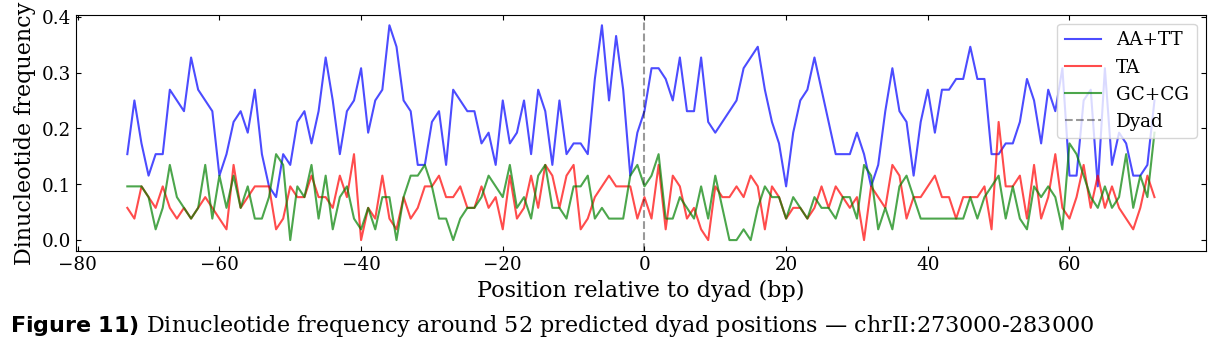

In [ ]:
# Compute dinucleotide frequency at each position relative to the dyad
positions = np.arange(-half, half)          # relative positions (0 = dyad center)
n_pos = len(positions)
all_dinucs = [a + b for a in 'ACGT' for b in 'ACGT']  # all 16 dinucleotides

# counts[dinuc][pos] = number of sequences with that dinucleotide at that relative position
counts = {dn: np.zeros(n_pos, dtype=int) for dn in all_dinucs}

for seq in dyad_sequences:
    for i in range(n_pos):
        dn = seq[i : i + 2]
        if dn in counts:
            counts[dn][i] += 1

# Normalise to frequency
n_seqs = len(dyad_sequences)
freq = {dn: counts[dn] / n_seqs for dn in all_dinucs}

# --- Bar plot ---
plot.new(fig_size=(12, 3))
plt.plot(positions, freq['AA'] + freq['TT'], label='AA+TT', color='blue', alpha=0.7)
plt.plot(positions, freq['TA'],               label='TA',    color='red',   alpha=0.7)
plt.plot(positions, freq['GC'] + freq['CG'],  label='GC+CG', color='green', alpha=0.7)
plt.axvline(0, color='black', linestyle='--', alpha=0.4, label='Dyad')
plt.xlabel('Position relative to dyad (bp)')
plt.ylabel('Dinucleotide frequency')
plt.legend()
plot.caption(f'Dinucleotide frequency around {n_seqs} predicted dyad positions — chrII:{start}-{end}')